In [1]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
style.use("fivethirtyeight")

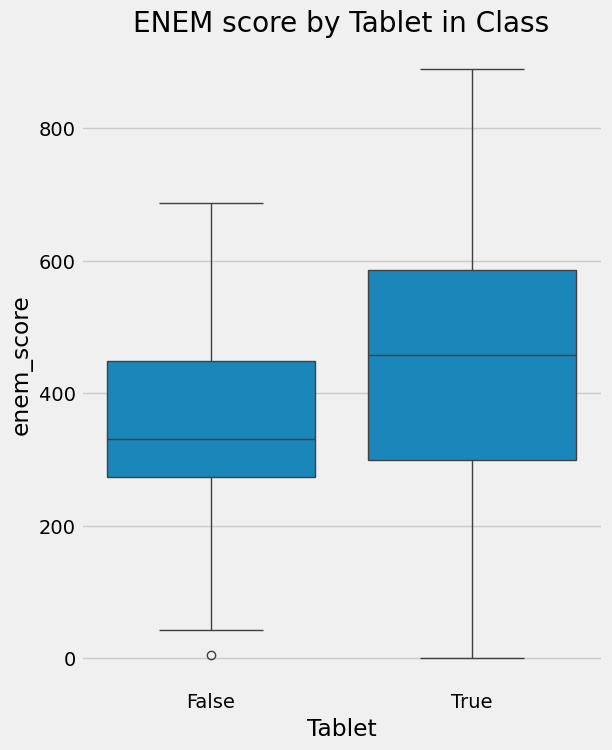

In [2]:
np.random.seed(123)
n = 100
tuition = np.random.normal(1000, 300, n).round()
tablet = np.random.binomial(1, expit((tuition - tuition.mean()) / tuition.std())).astype(bool)
enem_score = np.random.normal(200 - 50 * tablet + 0.7 * tuition, 200)
enem_score = (enem_score - enem_score.min()) / enem_score.max()
enem_score *= 1000

data = pd.DataFrame(dict(enem_score=enem_score, Tuition=tuition, Tablet=tablet))

plt.figure(figsize=(6,8))
sns.boxplot(y="enem_score", x="Tablet", data=data).set_title('ENEM score by Tablet in Class')
plt.show()

$T_i$ = 1 if tablet is true.
$Y_i$ = observed outcome
$Y_{0i}$ = potential outcome if not treatment
$Y_{1i}$ = potential outcome if treatment

$ATE = E[Y_1 - Y_0]$ <br>
$ATT = E[Y_1 - Y_0|T = 1]$ Look only at the people that were treated. ATT is the difference between their potential outcomes. <br>
Below, what you can see from simple difference of averages between the treated and the untreated
$E[Y|T = 1] - E[Y|T = 0] = E[Y_1|T = 1] - E[Y_0|T = 0] = E[Y_1|T = 1] - E[Y_0|T =1] + E[Y_0|T = 1]- E[Y_0|T =0]$

First part is ATT and second part is bias. Cannot estimate. How would the treated and untreated differ if all were not treated?
$E[Y_0|T = 1]$ is the counterfactual of the person that got treated. Causation is ATT. ATT + Bias is association.

In [3]:
a = pd.DataFrame(dict(
    i= [1,2,3,4],
    Y0=[500,600,800,700],
    Y1=[450,600,600,750],
    T= [0,0,1,1],
    Y= [500,600,600,750],
    TE=[-50,0,-200,50],
))
print("Wanted to see")
print(a)

b = pd.DataFrame(dict(
    i= [1,2,3,4],
    Y0=[500,600,np.nan,np.nan],
    Y1=[np.nan,np.nan,600,750],
    T= [0,0,1,1],
    Y= [500,600,600,750],
    TE=[np.nan,np.nan,np.nan,np.nan],
))
print("reality")
print(b)

Wanted to see
   i   Y0   Y1  T    Y   TE
0  1  500  450  0  500  -50
1  2  600  600  0  600    0
2  3  800  600  1  600 -200
3  4  700  750  1  750   50
reality
   i     Y0     Y1  T    Y  TE
0  1  500.0    NaN  0  500 NaN
1  2  600.0    NaN  0  600 NaN
2  3    NaN  600.0  1  600 NaN
3  4    NaN  750.0  1  750 NaN


If bias did not exist (by randomization of treatment), ATT = Association = ATE. Because in this case, treated and untreated would not differ. So,

$E[Y_1|T = 1] = E[Y_1], E[Y_0|T=1] = E[Y_0]$
$E[Y_1|T=1] - E[Y_0|T=1] = E[Y_1 - Y_0]$

Lecture 2: Randomised experiments
$(Y_0, Y_1) \perp T$ So $E(Y_0|T = 1) = E(Y_0|T=0) = E(Y_0)$

Lecture 4: Graphical Causal Models
$(Y_0, Y_1) \perp T|X$ <br>

Confounding bias: $X (Intelligence) \to T (Educ), T (Educ) \to Y (Wage), X (Intelligence) \to Y (Wage)$

Lecture 5: Regression

$Y_i = Y_{0i} + T_i(Y_{1i}-Y_{0i})$ <br>
$ATE = E[Y_{1}-Y_{0}]$ <br>
$exam_i = \beta_0 + \kappa Online_i + u_i$ <br>
$y_i = \beta_0 + \kappa T_i + \beta_1 X_{1i} + \dots + \beta_{k}X_{ki} + u_i$ <br>

Now, for non-random data

In [1]:
wage = pd.read_csv("./data/wage.csv").dropna()
model_1 = smf.ols('np.log(hwage) ~ educ', data=wage.assign(hwage=wage["wage"]/wage["hours"])).fit()
model_1.summary().tables[1]

NameError: name 'pd' is not defined

In [2]:
from matplotlib import pyplot as plt
from matplotlib import style
style.use("fivethirtyeight")

x = np.array(range(5, 20))
plt.plot(x, np.exp(model_1.params["Intercept"] + model_1.params["educ"] * x))
plt.xlabel("Years of Education")
plt.ylabel("Hourly Wage")
plt.title("Impact of Education on Hourly Wage")
plt.show()

controls = ['IQ', 'exper', 'tenure', 'age', 'married', 'black',
            'south', 'urban', 'sibs', 'brthord', 'meduc', 'feduc']

X = wage[controls].assign(intercep=1)
t = wage["educ"]
y = wage["lhwage"]

beta_aux = regress(t, X)
t_tilde = t - X.dot(beta_aux)

kappa = t_tilde.cov(y) / t_tilde.var()
kappa

model_2 = smf.ols('lhwage ~ educ +' + '+'.join(controls), data=wage).fit()
model_2.summary().tables[1]

NameError: name 'np' is not defined

Omitted Variable or Confounding Bias

$Wage_i = \alpha + \kappa Educ_i + \beta'A_i + u_i$, where $A_i$ represents ability
$\frac{Cov(Wage_i, Educ_i)}{Var(Educ_i)} = \kappa + \beta'\delta_A$, where $\delta_A$ is the coefficient of the regression of $A$ on $Educ$.

I’m sorry to bring it to you, but that will depend on our ability to argue in favor or against that fact that all confounders have been included in the model. Personally, I think they haven’t. For instance, we haven’t included family wealth. Even if we included family education, that can only be seen as a proxy for wealth. We’ve also not accounted for factors like personal ambition. It could be that ambition is what causes both more years of education and higher wage, so it is a confounder. This is to show that causal inference with non-random or observational data should always be taken with a grain of salt. We can never be sure that all confounders were accounted for.

https://stats.stackexchange.com/questions/244199/why-is-it-that-natural-log-changes-are-percentage-changes-what-is-about-logs-th

WRITE IT DOWN FOR CHAPTER 6

WRITE IT DOWN FOR CHAPTER 7

Chapter 8: IV!!!

$$ log(wage)_i = \beta_0 + \kappa Educ_i + \beta Abil_i + u_i $$
$$ Y_i = \beta_0 + \kappa T_i + \beta W_i + u_i$$

But we can only run
$$ Y_i = \beta_0 + \kappa T_i + v_i$$


Need to control for ability, which is not observed. Use something Cov(W,Z) ≠ 0, Cov(Z,v) = 0 

$Cov(Z,Y) = \kappa Cov(Z, T)$

$$\kappa = \frac{Cov(Z,Y)/Var(Z)}{Cov(Z,T)/Var(Z)} = \frac{\beta_{Y \sim Z}}{\beta_{T \sim Z}}$$
$$\kappa = \frac{\frac{\partial Y}{\partial Z}}{\frac{\partial T}{\partial Z}} = \frac{\partial Y}{\partial Z} \times \frac{\partial Z}{\partial T} = \frac{\partial Y}{\partial T}$$

$$ log(wage)_i = \beta_0 + \kappa Educ_i + \beta Abil_i + u_i $$
$$ Cov(Educ_i, Quarter\_birth) ≠ 0  + log(wage) \perp Quarter\_birth | Educ$$

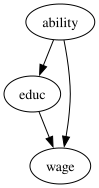

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import graphviz as gr
from linearmodels.iv import IV2SLS

%matplotlib inline

pd.set_option("display.max_columns", 5)
style.use("fivethirtyeight")

g = gr.Digraph()

g.edge("ability", "educ")
g.edge("ability", "wage")
g.edge("educ", "wage")
g

In [5]:
data = pd.read_csv("./data/ak91.csv")
data.head()

group_data = (data
              .groupby(["year_of_birth", "quarter_of_birth"])
              [["log_wage", "years_of_schooling"]]
              .mean()
              .reset_index()
              .assign(time_of_birth = lambda d: d["year_of_birth"] + (d["quarter_of_birth"])/4))

plt.figure(figsize=(15,6))
plt.plot(group_data["time_of_birth"], group_data["years_of_schooling"], zorder=-1)
for q in range(1, 5):
    x = group_data.query(f"quarter_of_birth=={q}")["time_of_birth"]
    y = group_data.query(f"quarter_of_birth=={q}")["years_of_schooling"]
    plt.scatter(x, y, marker="s", s=200, c=f"C{q}")
    plt.scatter(x, y, marker=f"${q}$", s=100, c=f"white")

plt.title("Years of Education by Quarter of Birth (first stage)")
plt.xlabel("Year of Birth")
plt.ylabel("Years of Schooling");

factor_data = data.assign(**{f"q{int(q)}": (data["quarter_of_birth"] == q).astype(int)
                             for q in data["quarter_of_birth"].unique()})

factor_data.head()

first_stage = smf.ols("years_of_schooling ~ C(year_of_birth) + C(state_of_birth) + q4", data=factor_data).fit()

print("q4 parameter estimate:, ", first_stage.params["q4"])
print("q4 p-value:, ", first_stage.pvalues["q4"])

plt.figure(figsize=(15,6))
plt.plot(group_data["time_of_birth"], group_data["log_wage"], zorder=-1)
for q in range(1, 5):
    x = group_data.query(f"quarter_of_birth=={q}")["time_of_birth"]
    y = group_data.query(f"quarter_of_birth=={q}")["log_wage"]
    plt.scatter(x, y, marker="s", s=200, c=f"C{q}")
    plt.scatter(x, y, marker=f"${q}$", s=100, c=f"white")

plt.title("Average Weekly Wage by Quarter of Birth (reduced form)")
plt.xlabel("Year of Birth")
plt.ylabel("Log Weekly Earnings");

reduced_form = smf.ols("log_wage ~ C(year_of_birth) + C(state_of_birth) + q4", data=factor_data).fit()

print("q4 parameter estimate:, ", reduced_form.params["q4"])
print("q4 p-value:, ", reduced_form.pvalues["q4"])

reduced_form.params["q4"] / first_stage.params["q4"] #0.08530286492085315 #This means that we should expect each additional year of school to increase wages by 8%.

#ALTERNATIVELY, WE COULD DO IT BY HAND
iv_by_hand = smf.ols("log_wage ~ C(year_of_birth) + C(state_of_birth) + years_of_schooling_fitted",
                     data=factor_data.assign(years_of_schooling_fitted=first_stage.fittedvalues)).fit()

iv_by_hand.params["years_of_schooling_fitted"] #0.0853028649208674 #As you can see, the parameters are exactly the same. #In practice, however, we don’t do IV by hand.


#Using linearmodels!
def parse(model, exog="years_of_schooling"):
    param = model.params[exog]
    se = model.std_errors[exog]
    p_val = model.pvalues[exog]
    print(f"Parameter: {param}")
    print(f"SE: {se}")
    print(f"95 CI: {(-1.96*se,1.96*se) + param}")
    print(f"P-value: {p_val}")
    
formula = 'log_wage ~ 1 + C(year_of_birth) + C(state_of_birth) + [years_of_schooling ~ q4]'
iv2sls = IV2SLS.from_formula(formula, factor_data).fit()
parse(iv2sls)

#Using multiple instruments
formula = 'log_wage ~ 1 + C(year_of_birth) + C(state_of_birth) + [years_of_schooling ~ q1+q2+q3]'
iv_many_zs = IV2SLS.from_formula(formula, factor_data).fit()
parse(iv_many_zs) #With all 3 dummies, the estimated return on education is now 0.1, which means that we should expect a 10% average increase on earnings for every additional year of education.

formula = "log_wage ~ years_of_schooling + C(state_of_birth) + C(year_of_birth) + C(quarter_of_birth)"
ols = IV2SLS.from_formula(formula, data=data).fit()
parse(ols) #The return on education is estimated to be lower with OLS than with 2SLS. #notice the confidence intervals. 2SLS has a much wider CI than the OLS estimate.

q4 parameter estimate:,  0.10085809272784482
q4 p-value:,  5.464829416657389e-15
q4 parameter estimate:,  0.008603484260145622
q4 p-value:,  0.0014949127183541374
Parameter: 0.0853028649580665
SE: 0.02554081280862408
95 CI: [0.03524287 0.13536286]
P-value: 0.0008381914596313766
Parameter: 0.10769370488924324
SE: 0.01955714900869993
95 CI: [0.06936169 0.14602572]
P-value: 3.657974678716869e-08
Parameter: 0.06732572817659133
SE: 0.00038839984390487577
95 CI: [0.06656446 0.06808699]
P-value: 0.0


IV: estimate ATE indirectly.
If impact of treatment on the outcome strong, then 2nd stage strong -> but problem if first-stage instrument weak (small correlation)

In [ ]:

np.random.seed(12)
n = 10000
X = np.random.normal(0, 2, n) # observable variable
U = np.random.normal(0, 2, n) # unobservable (omitted) variable
T = np.random.normal(1 + 0.5*U, 5, n) # treatment
Y = np.random.normal(2 + X - 0.5*U + 2*T, 5, n) # outcome

stddevs = np.linspace(0.1, 100, 50)
Zs = {f"Z_{z}": np.random.normal(T, s, n) for z, s in enumerate(stddevs)} # instruments with decreasing \mathrm{Cov}(Z, T)

sim_data = pd.DataFrame(dict(U=U, T=T, Y=Y)).assign(**Zs)

sim_data.head()

corr = (sim_data.corr()["T"]
        [lambda d: d.index.str.startswith("Z")])

corr.head()

se = []
ate = []
for z in range(len(Zs)):
    formula = f'Y ~ 1 + X + [T ~ Z_{z}]'
    iv = IV2SLS.from_formula(formula, sim_data).fit()
    se.append(iv.std_errors["T"])
    ate.append(iv.params["T"])


plot_data = pd.DataFrame(dict(se=se, ate=ate, corr=corr)).sort_values(by="corr")

plt.scatter(plot_data["corr"], plot_data["se"])
plt.xlabel("Corr(Z, T)")
plt.ylabel("IV Standard Error");
plt.title("Variance of the IV Estimates by 1st Stage Strength");

plt.scatter(plot_data["corr"], plot_data["ate"])
plt.fill_between(plot_data["corr"],
                 plot_data["ate"]+1.96*plot_data["se"],
                 plot_data["ate"]-1.96*plot_data["se"], alpha=.5)
plt.xlabel("Corr(Z, T)")
plt.ylabel("$\hat{ATE}$");
plt.title("IV ATE Estimates by 1st Stage Strength");